# Deutsch Algorithm
The Deutsch algorithm is a quantum algorithm that determines whether a function f: {0,1} → {0,1} is balanced or constant using a quantum oracle.

**Key Concepts:**
- **Constant function**: f(0) = f(1) (both outputs are the same)
- **Balanced function**: f(0) ≠ f(1) (outputs are different)

In [1]:
# Install required package
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "qiskit", "qiskit-aer"])

0

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

# Create a Deutsch circuit for a given oracle
def deutsch_algorithm(oracle_type):
    """
    Implements the Deutsch algorithm
    
    Parameters:
    oracle_type (str): Type of oracle - 'constant_0', 'constant_1', 'balanced_id', 'balanced_not'
    """
    
    # Create quantum and classical registers
    qr = QuantumRegister(2, 'q')
    cr = ClassicalRegister(1, 'c')
    
    # Create quantum circuit
    circuit = QuantumCircuit(qr, cr, name='Deutsch')
    
    # Step 1: Initialize qubits
    # q0 = |0⟩, q1 = |0⟩
    circuit.barrier(label='Initialize')
    
    # Step 2: Apply X gate to q1 (makes it |1⟩)
    circuit.x(qr[1])
    
    # Step 3: Apply Hadamard gates to both qubits
    circuit.h(qr[0])
    circuit.h(qr[1])
    circuit.barrier(label='Hadamard')
    
    # Step 4: Apply oracle
    circuit.barrier(label='Oracle')
    
    if oracle_type == 'constant_0':
        # f(x) = 0: Identity (do nothing)
        circuit.id(qr[0])
        
    elif oracle_type == 'constant_1':
        # f(x) = 1: Apply Z gate to q0
        circuit.z(qr[0])
        
    elif oracle_type == 'balanced_id':
        # f(x) = x: CNOT gate
        circuit.cx(qr[0], qr[1])
        
    elif oracle_type == 'balanced_not':
        # f(x) = NOT x: CNOT followed by X on q0
        circuit.cx(qr[0], qr[1])
        circuit.x(qr[0])
    
    circuit.barrier(label='Oracle End')
    
    # Step 5: Apply Hadamard gate to q0
    circuit.h(qr[0])
    circuit.barrier(label='Final Hadamard')
    
    # Step 6: Measure q0
    circuit.measure(qr[0], cr[0])
    
    return circuit

# Test all four oracle types
oracle_types = ['constant_0', 'constant_1', 'balanced_id', 'balanced_not']
circuits = {}
results = {}

print("Building Deutsch Algorithm Circuits for Different Oracles:\n")
print("=" * 60)

for oracle_type in oracle_types:
    circuit = deutsch_algorithm(oracle_type)
    circuits[oracle_type] = circuit
    print(f"\nOracle Type: {oracle_type}")
    print(f"Expected Result: {'Constant (0)' if 'constant' in oracle_type else 'Balanced (1)'}")

# Display one circuit as example
print("\n" + "=" * 60)
print("Example Circuit (constant_0 oracle):")
print("=" * 60)
print(circuits['constant_0'])

Building Deutsch Algorithm Circuits for Different Oracles:


Oracle Type: constant_0
Expected Result: Constant (0)

Oracle Type: constant_1
Expected Result: Constant (0)

Oracle Type: balanced_id
Expected Result: Balanced (1)

Oracle Type: balanced_not
Expected Result: Balanced (1)

Example Circuit (constant_0 oracle):
      Initialize ┌───┐      Hadamard  Oracle ┌───┐ Oracle End ┌───┐»
q_0: ─────░──────┤ H ├─────────░────────░────┤ I ├─────░──────┤ H ├»
          ░      ├───┤┌───┐    ░        ░    └───┘     ░      └───┘»
q_1: ─────░──────┤ X ├┤ H ├────░────────░──────────────░───────────»
          ░      └───┘└───┘    ░        ░              ░           »
c: 1/══════════════════════════════════════════════════════════════»
                                                                   »
«      Final Hadamard ┌─┐
«q_0: ───────░────────┤M├
«            ░        └╥┘
«q_1: ───────░─────────╫─
«            ░         ║ 
«c: 1/═════════════════╩═
«                      0 


In [3]:
# Run the circuits and collect results
simulator = AerSimulator()
num_shots = 1000

print("\n" + "=" * 60)
print("Running Deutsch Algorithm Simulations")
print("=" * 60)

for oracle_type in oracle_types:
    # Transpile and execute
    job = simulator.run(circuits[oracle_type], shots=num_shots)
    result = job.result()
    counts = result.get_counts()
    results[oracle_type] = counts
    
    # Extract measurement result
    most_common = max(counts, key=counts.get)
    
    print(f"\n{oracle_type}:")
    print(f"  Measurement result: {most_common}")
    print(f"  Counts: {counts}")
    
    if most_common == '0':
        print(f"  → Function is CONSTANT")
    else:
        print(f"  → Function is BALANCED")


Running Deutsch Algorithm Simulations

constant_0:
  Measurement result: 0
  Counts: {'0': 1000}
  → Function is CONSTANT

constant_1:
  Measurement result: 1
  Counts: {'1': 1000}
  → Function is BALANCED

balanced_id:
  Measurement result: 1
  Counts: {'1': 1000}
  → Function is BALANCED

balanced_not:
  Measurement result: 1
  Counts: {'1': 1000}
  → Function is BALANCED


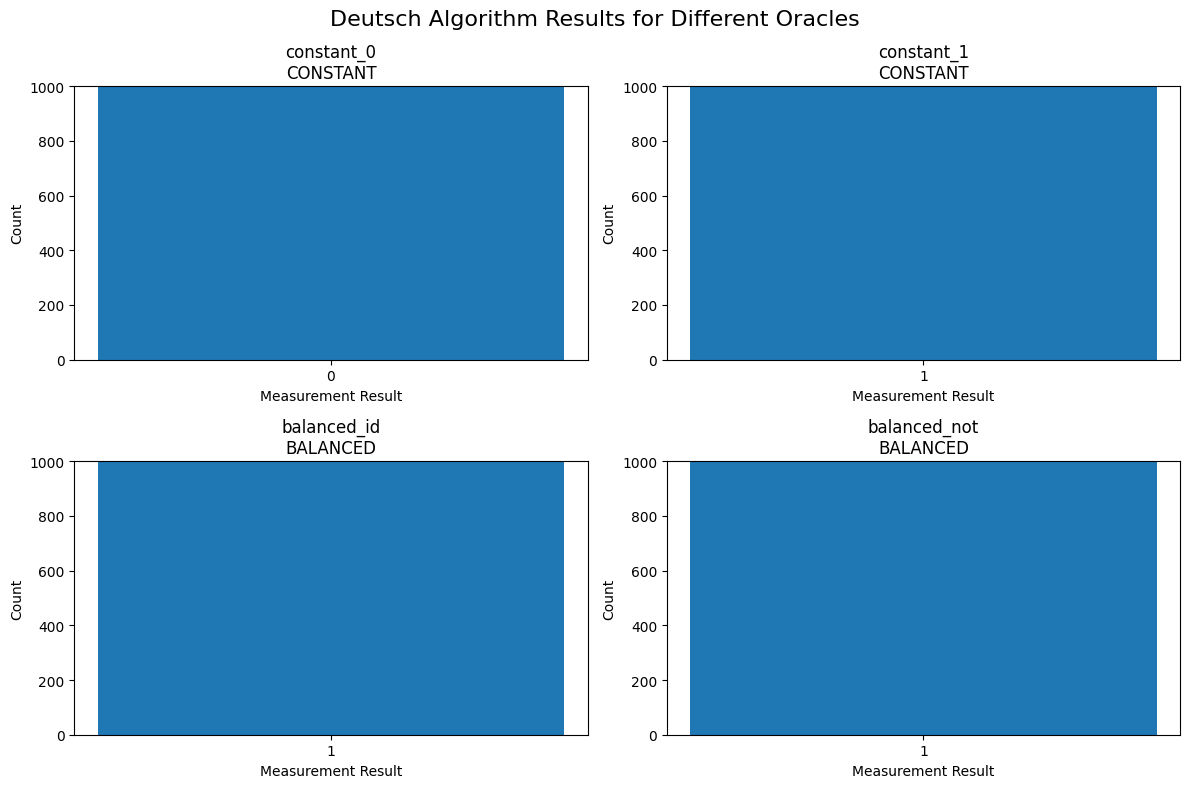


Deutsch Algorithm Summary
The Deutsch algorithm determines if a function is constant or balanced
by measuring only ONE qubit in a superposition state - a quantum speedup!
Measurement result 0 → Constant function
Measurement result 1 → Balanced function


In [4]:
# Visualize results
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Deutsch Algorithm Results for Different Oracles', fontsize=16)

for idx, oracle_type in enumerate(oracle_types):
    ax = axes[idx // 2, idx % 2]
    counts = results[oracle_type]
    
    # Create bar chart
    labels = list(counts.keys())
    values = list(counts.values())
    colors = ['#1f77b4', '#ff7f0e']
    
    ax.bar(labels, values, color=colors[:len(labels)])
    ax.set_xlabel('Measurement Result')
    ax.set_ylabel('Count')
    ax.set_title(f'{oracle_type}\n{"CONSTANT" if "constant" in oracle_type else "BALANCED"}')
    ax.set_ylim(0, num_shots)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("Deutsch Algorithm Summary")
print("=" * 60)
print("The Deutsch algorithm determines if a function is constant or balanced")
print("by measuring only ONE qubit in a superposition state - a quantum speedup!")
print("Measurement result 0 → Constant function")
print("Measurement result 1 → Balanced function")